# US Accidents Exploratory Data Analysis


**Downloading the dataset**

In [1]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation and Cleaning

1. Load the file using Pandas     
2. Look at some information about the data & the columns         
3. Fix any missing or incorrect values


In [2]:
data = pd.read_csv('US_Accidents_March23.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'US_Accidents_March23.csv'

In [ ]:
data

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.010,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.010,...,False,False,False,False,True,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.002480,-117.379360,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.766960,-117.148060,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.775450,-117.847790,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.992460,-118.403020,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day


In [ ]:
data.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [ ]:
data.describe().count()

Severity             8
Start_Lat            8
Start_Lng            8
End_Lat              8
End_Lng              8
Distance(mi)         8
Temperature(F)       8
Wind_Chill(F)        8
Humidity(%)          8
Pressure(in)         8
Visibility(mi)       8
Wind_Speed(mph)      8
Precipitation(in)    8
dtype: int64

In [ ]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numeric_data = data.select_dtypes(include=numerics)

len(numeric_data.columns)


13

### Finding any missing values 

In [ ]:
data.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

**Percentage of Missing Values per column**

In [ ]:
missing_perc_col = data.isnull().sum().sort_values(ascending=False) / len(data) * 100

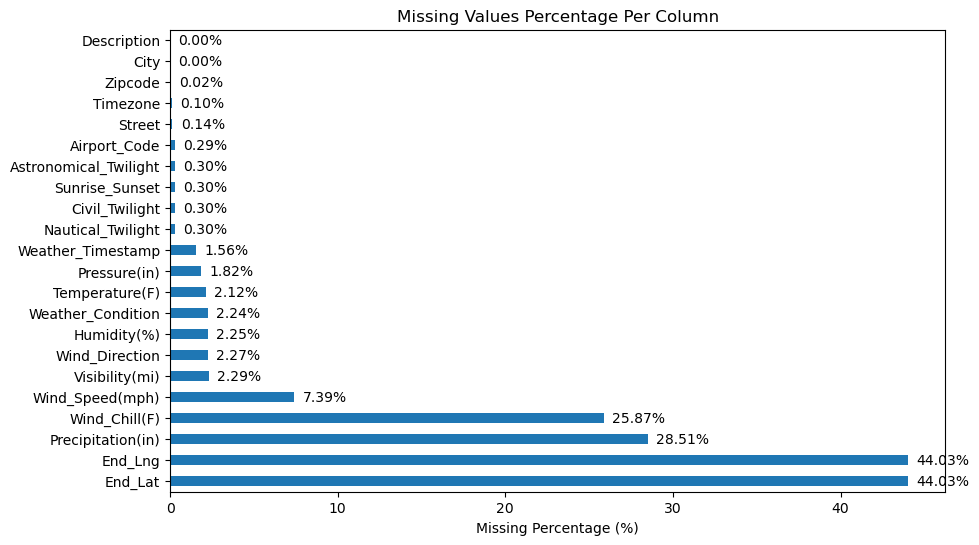

In [ ]:
missing_perc_col = (data.isnull().sum().sort_values(ascending=False) / len(data) * 100)

ax = missing_perc_col[missing_perc_col != 0].plot(kind='barh', figsize=(10,6))

plt.xlabel("Missing Percentage (%)")
plt.title("Missing Values Percentage Per Column")

# Add numbers on bars
for i, v in enumerate(missing_perc_col[missing_perc_col != 0]):
    ax.text(v + 0.5, i, f"{v:.2f}%", va='center')

plt.show()


In [ ]:
data_copy = data.copy()

In [ ]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [ ]:
missing_data_per = data_copy.isnull().sum().sort_values(ascending=False) / len(data_copy) * 100
missing_data_per

End_Lat                  44.029355
End_Lng                  44.029355
Precipitation(in)        28.512858
Wind_Chill(F)            25.865904
Wind_Speed(mph)           7.391355
Visibility(mi)            2.291524
Wind_Direction            2.267043
Humidity(%)               2.253301
Weather_Condition         2.244438
Temperature(F)            2.120143
Pressure(in)              1.820288
Weather_Timestamp         1.555666
Nautical_Twilight         0.300787
Civil_Twilight            0.300787
Sunrise_Sunset            0.300787
Astronomical_Twilight     0.300787
Airport_Code              0.292881
Street                    0.140637
Timezone                  0.101030
Zipcode                   0.024779
City                      0.003274
Description               0.000065
Traffic_Signal            0.000000
Roundabout                0.000000
Station                   0.000000
Stop                      0.000000
Traffic_Calming           0.000000
Country                   0.000000
Turning_Loop        

In [ ]:
cols_to_drop = missing_data_per[missing_data_per > 40].index
data_copy = data_copy.drop(columns = cols_to_drop)

In [ ]:
data_copy.shape

(7728394, 44)

## Exploratory Analysis and Visualization 

**Columns We'll Analyse**

1.City      
2.Start Time        
3.Start Lat,Start Long      
4.Temperature       
5.Weather Condition     

In [ ]:
data_copy.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

### City 

In [ ]:
data_copy.City

0                Dayton
1          Reynoldsburg
2          Williamsburg
3                Dayton
4                Dayton
               ...     
7728389       Riverside
7728390       San Diego
7728391          Orange
7728392     Culver City
7728393        Highland
Name: City, Length: 7728394, dtype: object

In [ ]:
cities_by_accidents = data_copy.City.value_counts()

In [ ]:
# Top 20 cities by highest number of accidents

cities_by_accidents[:20]

City
Miami            186917
Houston          169609
Los Angeles      156491
Charlotte        138652
Dallas           130939
Orlando          109733
Austin            97359
Raleigh           86079
Nashville         72930
Baton Rouge       71588
Atlanta           68186
Sacramento        66264
San Diego         55504
Phoenix           53974
Minneapolis       51488
Richmond          48845
Oklahoma City     46092
Jacksonville      42447
Tucson            39304
Columbia          38178
Name: count, dtype: int64

In [ ]:
'NY' in data.State

False

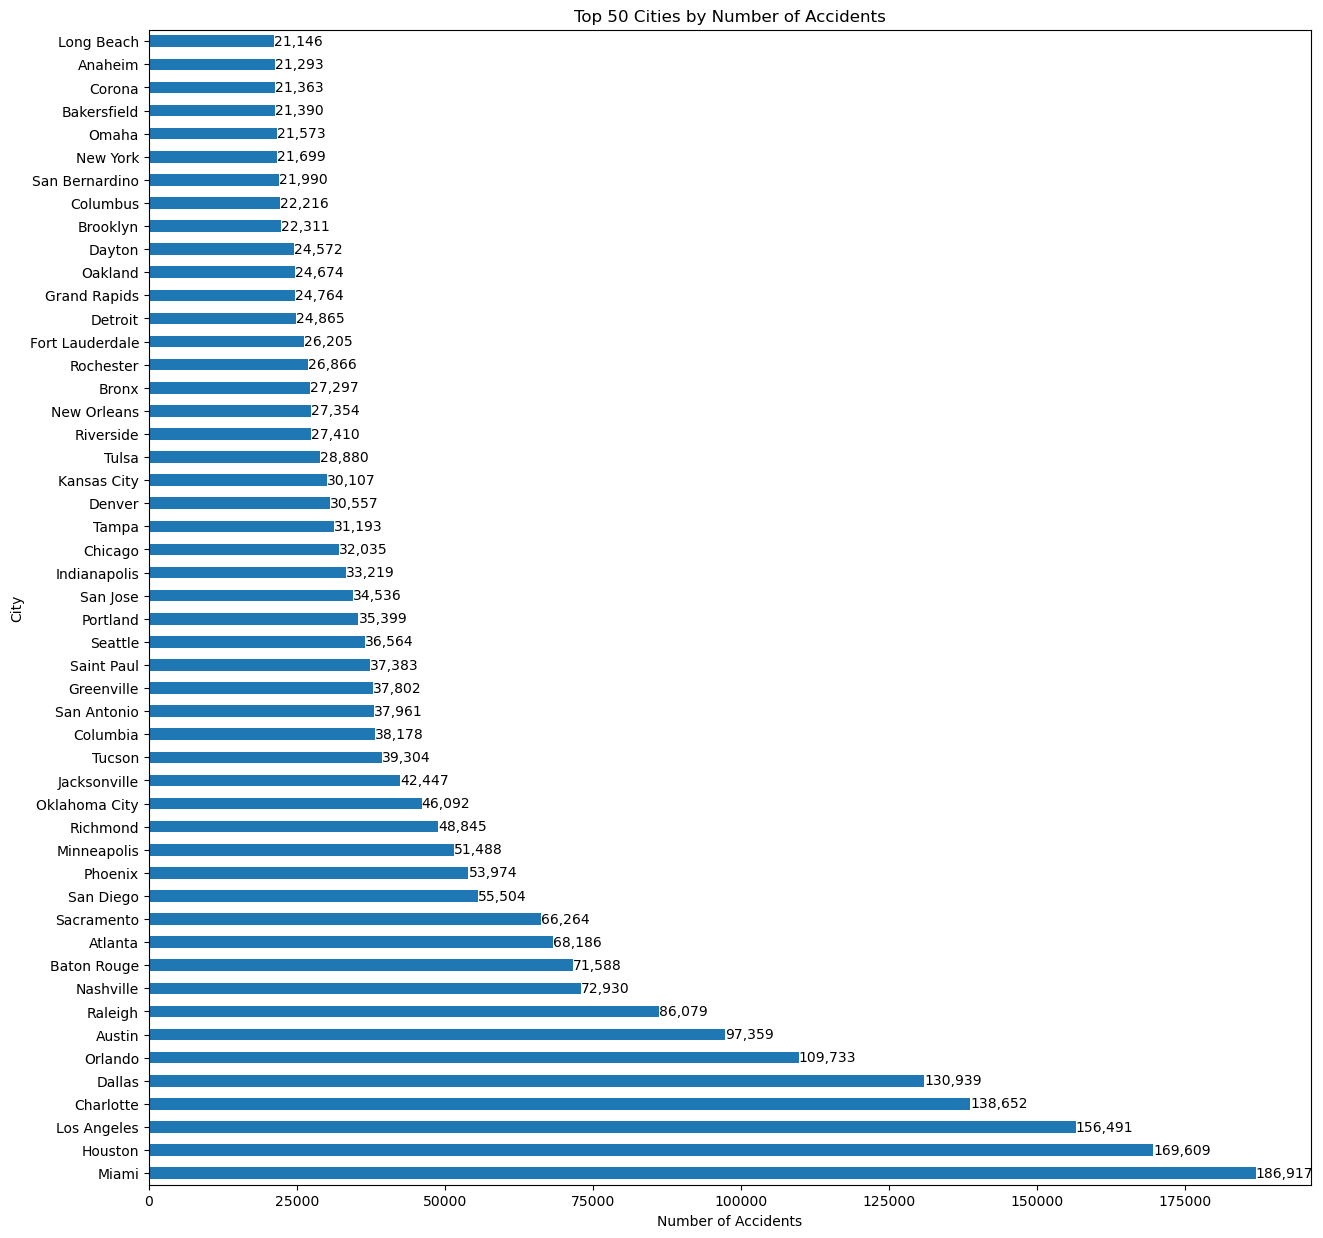

In [ ]:

ax = cities_by_accidents[:50].plot(kind='barh', figsize=(15,15))

# Add numbers on bars
for i, v in enumerate(cities_by_accidents[:50]):
    ax.text(v + 0.5, i, f"{v:,}", va='center')   # or format as needed

plt.title("Top 50 Cities by Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("City")

plt.show()


<Axes: xlabel='count', ylabel='Count'>

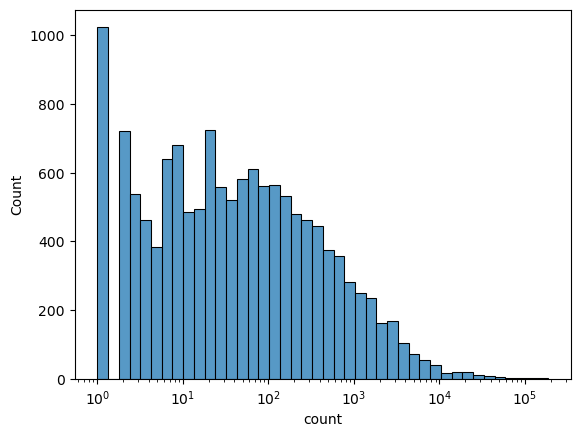

In [ ]:
sns.histplot(cities_by_accidents,log_scale=True)

In [ ]:

high_accident_cities = cities_by_accidents[cities_by_accidents >= 1000]
low_accident_cities = cities_by_accidents[cities_by_accidents < 1000]

In [ ]:
len(high_accident_cities) / len(cities_by_accidents) * 100

8.904810644831116

<Axes: xlabel='count', ylabel='Count'>

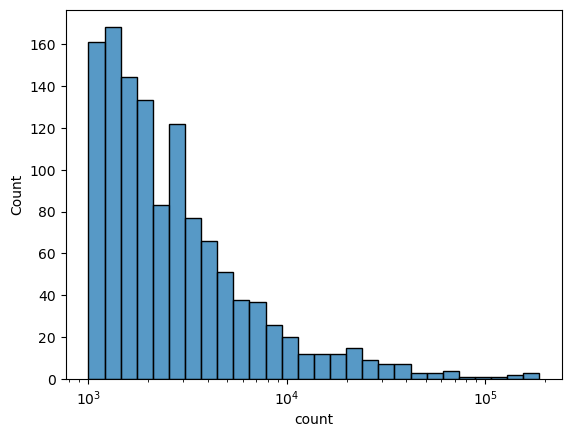

In [ ]:
sns.histplot(high_accident_cities,log_scale=True)


<Axes: xlabel='count', ylabel='Count'>

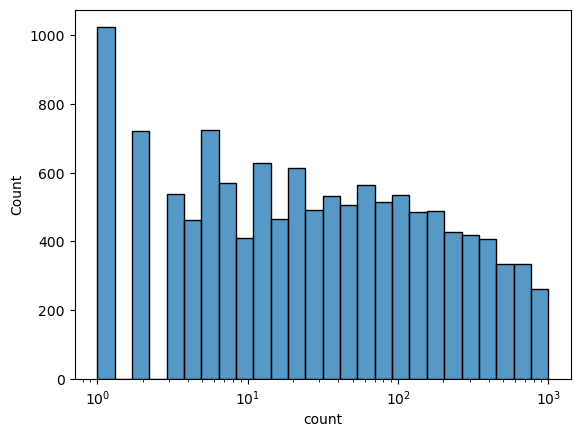

In [ ]:
sns.histplot(low_accident_cities,log_scale=True)

In [ ]:
cities_by_accidents[cities_by_accidents == 1]

City
Lake Andes                      1
Catoctin                        1
Duck Hill                       1
Westbrookville                  1
Saint Croix                     1
                               ..
Benkelman                       1
Old Appleton                    1
Wildrose                        1
Mc Nabb                         1
American Fork-Pleasant Grove    1
Name: count, Length: 1023, dtype: int64

### Start Time

In [ ]:
data_copy.Start_Time

0          2016-02-08 05:46:00
1          2016-02-08 06:07:59
2          2016-02-08 06:49:27
3          2016-02-08 07:23:34
4          2016-02-08 07:39:07
                  ...         
7728389    2019-08-23 18:03:25
7728390    2019-08-23 19:11:30
7728391    2019-08-23 19:00:21
7728392    2019-08-23 19:00:21
7728393    2019-08-23 18:52:06
Name: Start_Time, Length: 7728394, dtype: object

In [ ]:
data_copy['Start_Time'] = pd.to_datetime(
    data_copy['Start_Time'],
    format='mixed',      # pandas 2.0+ feature
    errors='coerce'
)


In [ ]:
# Extracting hours from one row
data_copy.Start_Time[0].hour

5

In [ ]:
# Extracting hours from whole column
data_copy['Hours'] = data_copy['Start_Time'].dt.hour

In [ ]:
data_copy[:10]

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hours
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,...,False,False,False,False,False,Night,Night,Night,Night,5
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,...,False,False,False,False,False,Night,Night,Night,Day,6
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,...,False,False,False,True,False,Night,Night,Day,Day,6
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,...,False,False,False,False,False,Night,Day,Day,Day,7
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,...,False,False,False,True,False,Day,Day,Day,Day,7
5,A-6,Source2,3,2016-02-08 07:44:26,2016-02-08 08:14:26,40.100590,-82.925194,0.01,Accident on I-270 Outerbelt Northbound near Ex...,Westerville Rd,...,False,False,False,False,False,Day,Day,Day,Day,7
6,A-7,Source2,2,2016-02-08 07:59:35,2016-02-08 08:29:35,39.758274,-84.230507,0.00,Accident on Oakridge Dr at Woodward Ave. Expec...,N Woodward Ave,...,False,False,False,False,False,Day,Day,Day,Day,7
7,A-8,Source2,3,2016-02-08 07:59:58,2016-02-08 08:29:58,39.770382,-84.194901,0.01,Accident on I-75 Southbound at Exit 54B Grand ...,N Main St,...,False,False,False,False,False,Day,Day,Day,Day,7
8,A-9,Source2,2,2016-02-08 08:00:40,2016-02-08 08:30:40,39.778061,-84.172005,0.00,Accident on Notre Dame Ave at Warner Ave. Expe...,Notre Dame Ave,...,False,False,False,False,False,Day,Day,Day,Day,8
9,A-10,Source2,3,2016-02-08 08:10:04,2016-02-08 08:40:04,40.100590,-82.925194,0.01,Right hand shoulder blocked due to accident on...,Westerville Rd,...,False,False,False,False,False,Day,Day,Day,Day,8


In [ ]:
data_copy.Hours.value_counts().sort_index(ascending=True)

Hours
0     112378
1      97071
2      93227
3      83863
4     159852
5     228182
6     405837
7     587472
8     577576
9     363034
10    342706
11    355040
12    355001
13    396445
14    448846
15    525855
16    581969
17    576015
18    432042
19    295121
20    225226
21    191452
22    167645
23    126539
Name: count, dtype: int64

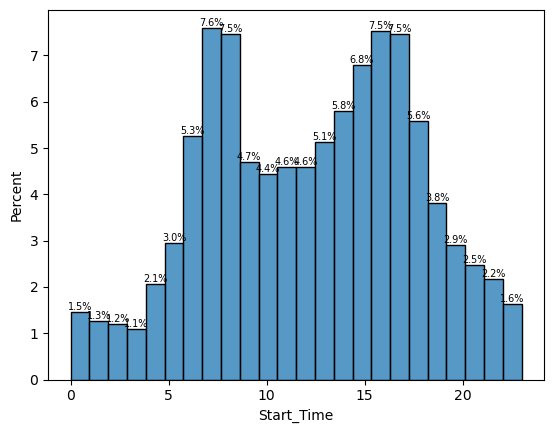

In [ ]:
import numpy as np

vals = data_copy['Start_Time'].dt.hour
ax = sns.histplot(vals, bins=24, stat='percent',common_norm=False)

# Add labels on bars
for p in ax.patches:
    percentage = f"{p.get_height():.1f}%"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.text(x, y, percentage, ha='center', va='bottom', fontsize=7)

plt.show()



**-- A high percentage of accident occurs between 7am to 9am (probably people in a hurry to get to a work and same in the evening to head towards home)**       
**-- Next Highest Percentage is 3pm to 6pm**

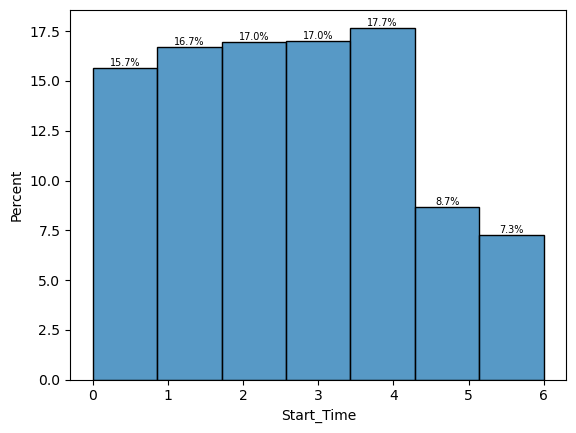

In [ ]:
import numpy as np

vals = data_copy['Start_Time'].dt.dayofweek
ax = sns.histplot(vals, bins=7, stat='percent',common_norm=False)

# Add labels on bars
for p in ax.patches:
    percentage = f"{p.get_height():.1f}%"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.text(x, y, percentage, ha='center', va='bottom', fontsize=7)

plt.show()

### Is the distribution of accidents by hour the same on weekends as on weekdays

In [ ]:
weekend_data = data_copy.Start_Time[(data_copy.Start_Time.dt.dayofweek == 6) | (data_copy.Start_Time.dt.dayofweek == 5)]

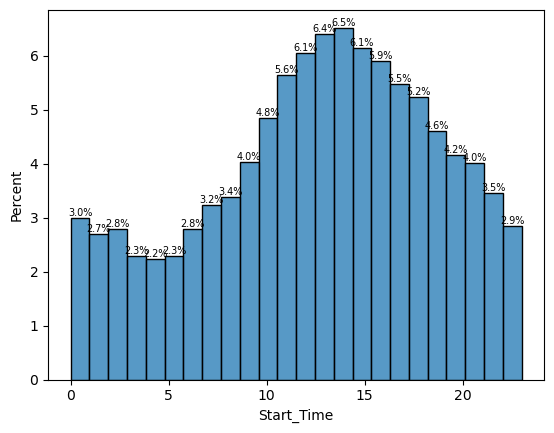

In [ ]:
import numpy as np

vals = weekend_data
ax = sns.histplot(vals.dt.hour, bins=24, stat='percent',common_norm=False)

# Add labels on bars
for p in ax.patches:
    percentage = f"{p.get_height():.1f}%"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.text(x, y, percentage, ha='center', va='bottom', fontsize=7)

plt.show()

In [ ]:
sunday_data = data_copy.Start_Time[(data_copy.Start_Time.dt.dayofweek == 6)]

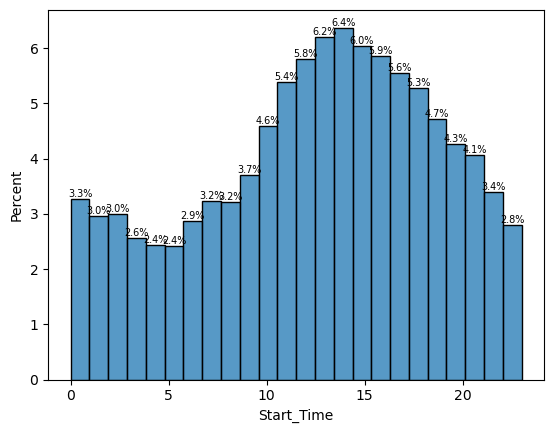

In [ ]:
import numpy as np

vals = sunday_data
ax = sns.histplot(vals.dt.hour, bins=24, stat='percent',common_norm=False)

# Add labels on bars
for p in ax.patches:
    percentage = f"{p.get_height():.1f}%"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.text(x, y, percentage, ha='center', va='bottom', fontsize=7)

### On Sundays,the peak occurs between 10 am and 3pm,unlike weekdays.

In [ ]:
monday_data = data_copy.Start_Time[(data_copy.Start_Time.dt.dayofweek == 0)]

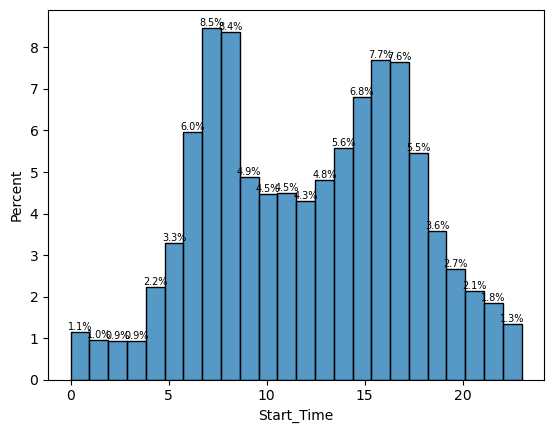

In [ ]:
import numpy as np

vals = monday_data
ax = sns.histplot(vals.dt.hour, bins=24, stat='percent',common_norm=False)

# Add labels on bars
for p in ax.patches:
    percentage = f"{p.get_height():.1f}%"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.text(x, y, percentage, ha='center', va='bottom', fontsize=7)

<Axes: xlabel='Start_Time', ylabel='Percent'>

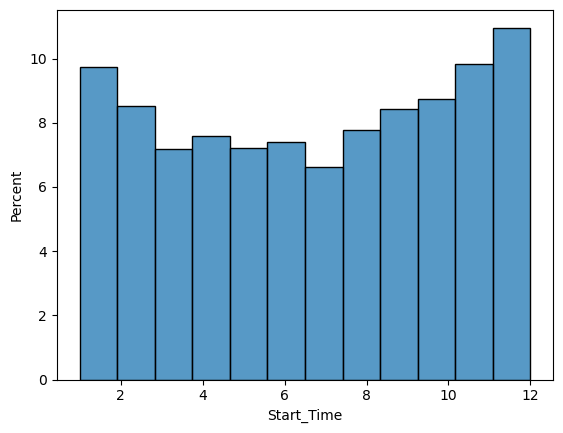

In [ ]:
sns.histplot(data_copy.Start_Time.dt.month,bins=12,kde=False,common_norm=False,stat='percent')

In [ ]:
# Checking Accidents during 2019

data_2019 = data_copy[data_copy.Start_Time.dt.year == 2019]

<Axes: xlabel='Start_Time', ylabel='Percent'>

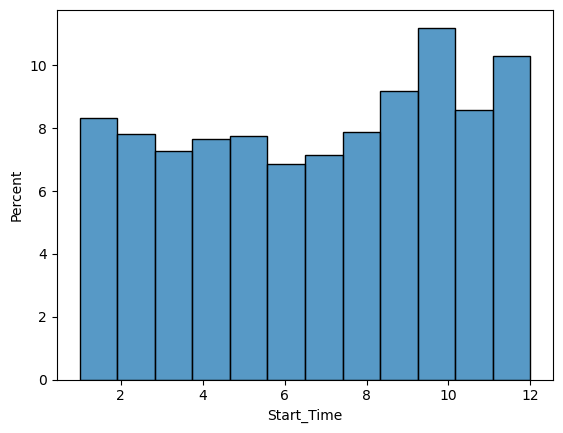

In [ ]:
sns.histplot(data_2019.Start_Time.dt.month,bins=12,kde=False,common_norm=False,stat = 'percent')

In [ ]:
# Checking the data for 2016

data_2016 = data_copy[data_copy.Start_Time.dt.year == 2016]

<Axes: xlabel='Start_Time', ylabel='Percent'>

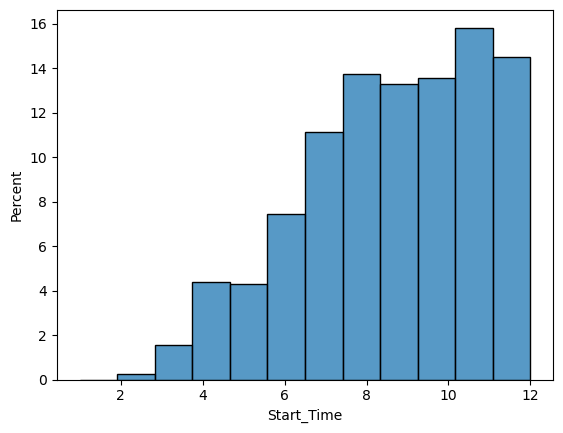

In [ ]:
sns.histplot(data_2016.Start_Time.dt.month,bins=12,kde=False,common_norm=False,stat='percent')

In [ ]:
data_2019_Source1 = data_2019[data_2019.Source == 'Source1']

<Axes: xlabel='Start_Time', ylabel='Percent'>

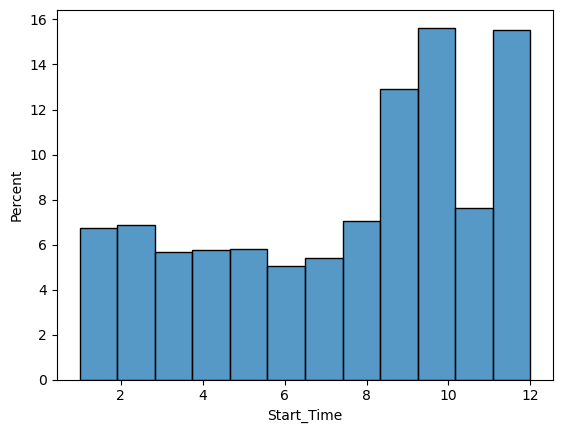

In [ ]:
sns.histplot(data_2019_Source1.Start_Time.dt.month,bins=12,kde=False,common_norm=False,stat='percent')

In [ ]:
data_2019_Source2 = data_2019[data_2019.Source == 'Source2']

<Axes: xlabel='Start_Time', ylabel='Percent'>

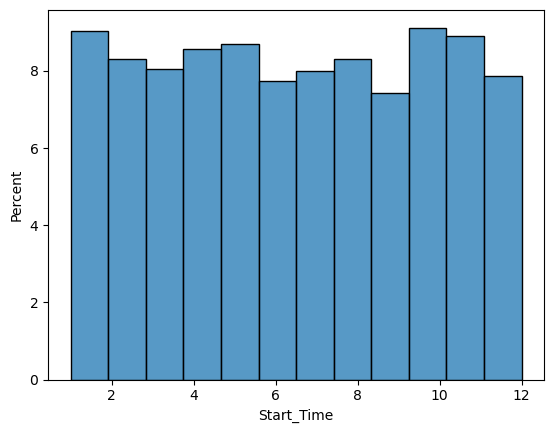

In [ ]:
sns.histplot(data_2019_Source2.Start_Time.dt.month,bins=12,kde=False,common_norm=False,stat='percent')

<Axes: ylabel='count'>

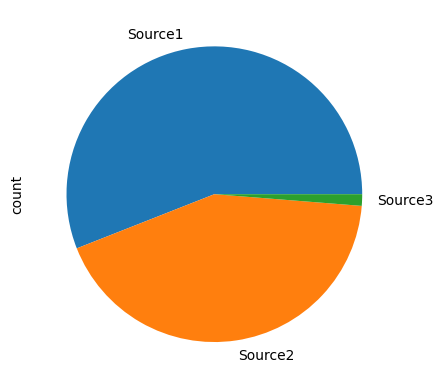

In [ ]:
data_copy.Source.value_counts().plot(kind='pie')

### Can you explain the month-wise trend of accidents ?

**- Much Data is missing for the year 2016.**       
**- There seems to be some issue with Source1 Data**

### Start Latitude & Longitude

In [ ]:
data_copy.Start_Lat	

0          39.865147
1          39.928059
2          39.063148
3          39.747753
4          39.627781
             ...    
7728389    34.002480
7728390    32.766960
7728391    33.775450
7728392    33.992460
7728393    34.133930
Name: Start_Lat, Length: 7728394, dtype: float64

In [ ]:
data_copy.Start_Lng

0          -84.058723
1          -82.831184
2          -84.032608
3          -84.205582
4          -84.188354
              ...    
7728389   -117.379360
7728390   -117.148060
7728391   -117.847790
7728392   -118.403020
7728393   -117.230920
Name: Start_Lng, Length: 7728394, dtype: float64

In [ ]:
sample_data = data_copy.sample(int(0.1 * len(data_copy)))

<Axes: xlabel='Start_Lng', ylabel='Start_Lat'>

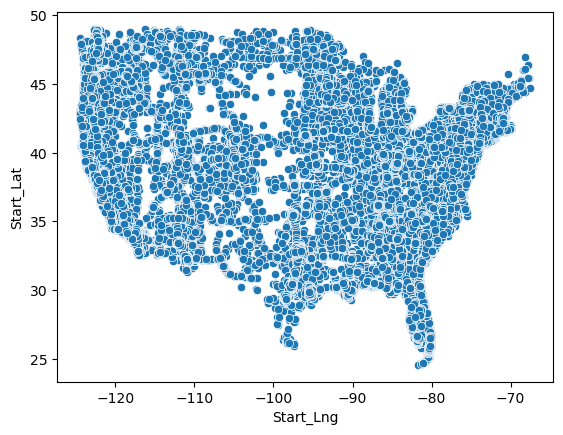

In [ ]:
sns.scatterplot(x=sample_data.Start_Lng,y=sample_data.Start_Lat)

## Ask & answer questions

1.Are there more accidents in warmer or colder area ?       
2.Which 5 states have the highest number of accidents?      
3.Does New York show up in the data ? If Yes ,then why is the count lower if it is the most populated city.     
4.Among the top 100 cities in number of accidents ,which states do they belong to most frequenty ?      
5.What time of the day are accidents most frequent in ?    **-- ANSWERED **     
6.Which days of the week have the most accidents ?      
7.Which months have the most accidents ?        
8.What is the trend of the accidents year over year (increasing/decreasing ?)       

## Summary and Conclusion

**Insights :**

1.No data from New York     
2.The number of accidents per city descreases exponentially     
3.Less than 10% of cities have more than 1000 yearly accidents.          
4.Over 1030 cities have reported just one accident (need to investigate).        
